In [1]:
import pandas as pd
from google.colab import files

# Load the dataset from Google Drive
url = "https://drive.google.com/file/d/18X-VwW6SA3fsgkYOSauHeO_34_BXT2u4/view?usp=drivesdk"
file_id = url.split("/d/")[1].split("/view")[0]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

try:
    df = pd.read_csv(download_url)
except Exception as e:
    print(f"Error loading the dataset: {e}")
    exit()

# List of columns to KEEP
columns_to_keep = [ "winner",
    "cumulative_runs",
    "cumulative_wickets",
    "current_run_rate",
    "required_run_rate",
                    "inning",
    "id",
    "batting_team",
    "bowling_team",
    "venue",
]

# Get a list of columns to remove
columns_to_remove = [col for col in df.columns if col not in columns_to_keep]

# Remove the unwanted columns
try:
    df_filtered = df.drop(columns=columns_to_remove, errors='ignore')
    print("Unwanted columns removed successfully.")
    print(df_filtered.head(10)) # Print top 10 rows

except KeyError as e:
    print(f"Error removing columns: {e}")

# Save the filtered DataFrame to a new CSV file
csv_file_name = "filtered_cricket_data.csv"
df_filtered.to_csv(csv_file_name, index=False)
print(f"Filtered data saved to {csv_file_name}")

# Download the CSV file
try:
    files.download(csv_file_name)
    print("File download initiated.")
except Exception as e:
    print(f"Error during download: {e}")

<ipython-input-1-effdeebff8e7>:10: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(download_url)


Unwanted columns removed successfully.
       id                 winner  inning           batting_team  \
0  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
1  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
2  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
3  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
4  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
5  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
6  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
7  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
8  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
9  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   

                  bowling_team  cumulative_runs  cumulative_wickets  \
0  Royal Challengers Bangalore                1                   0   
1  Royal Challengers Bangalore                1                   0   
2  Royal C

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File download initiated.


In [2]:
import pandas as pd

# Load the dataset
file_path = "filtered_cricket_data.csv"  # Update with your actual file path
df = pd.read_csv(file_path)

# Find the final cumulative runs of the first innings for each match (last entry of inning 1)
first_innings_targets = df[df["inning"] == 1].groupby("id")["cumulative_runs"].max().rename("target")

# Merge the target with the dataset, assigning it to the second innings
df = df.merge(first_innings_targets, on="id", how="left")

# Assign target only for second innings, set first innings' target as 0
df["target"] = df.apply(lambda row: row["target"] if row["inning"] == 2 else 0, axis=1)

# Create the binary win column (1 if batting team wins, 0 otherwise)
df['win'] = (df['batting_team'] == df['winner']).astype(int)

# Save the updated dataset
updated_file_path = "filtered_cricket_data_with_target_win.csv"
df.to_csv(updated_file_path, index=False)

print("Updated dataset saved as 'filtered_cricket_data_with_target_win.csv'")

<ipython-input-2-10130e238627>:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Updated dataset saved as 'filtered_cricket_data_with_target_win.csv'


In [ ]:
print(df.head(10))

       id                 winner  inning           batting_team  \
0  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
1  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
2  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
3  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
4  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
5  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
6  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
7  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
8  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   
9  335982  Kolkata Knight Riders       1  Kolkata Knight Riders   

                  bowling_team  cumulative_runs  cumulative_wickets  \
0  Royal Challengers Bangalore                1                   0   
1  Royal Challengers Bangalore                1                   0   
2  Royal Challengers Bangalore                2  

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the dataset
file_path = "filtered_cricket_data_with_target_win.csv"  # Update with your actual file path
df = pd.read_csv(file_path)

# Initialize LabelEncoder
label_encoders = {}
categorical_columns = ["winner", "batting_team", "bowling_team", "venue"]

# Apply Label Encoding to categorical columns
for col in categorical_columns:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

# Convert 'required_run_rate' to numeric, forcing errors to NaN and then filling them with 0
df["required_run_rate"] = pd.to_numeric(df["required_run_rate"], errors="coerce").fillna(0)

# Save the encoded dataset
encoded_file_path = "encoded_cricket_data.csv"  # Change the path if needed
df.to_csv(encoded_file_path, index=False)

# Print top 10 rows
print(df.head(10))

print(f"Encoded dataset saved to: {encoded_file_path}")

<ipython-input-3-69927806c3a7>:6: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


       id  winner  inning  batting_team  bowling_team  cumulative_runs  \
0  335982       6       1             6            13                1   
1  335982       6       1             6            13                1   
2  335982       6       1             6            13                2   
3  335982       6       1             6            13                2   
4  335982       6       1             6            13                2   
5  335982       6       1             6            13                2   
6  335982       6       1             6            13                3   
7  335982       6       1             6            13                3   
8  335982       6       1             6            13                7   
9  335982       6       1             6            13               11   

   cumulative_wickets  current_run_rate  required_run_rate  venue  target  win  
0                   0              0.00                0.0     17       0    1  
1                   0  

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
file_path = "encoded_cricket_data.csv"  # Update with your actual file path
df = pd.read_csv(file_path)

# Selecting features and target variable
features = ["batting_team", "bowling_team", "inning", "cumulative_wickets",
            "current_run_rate", "required_run_rate", "target"]
target = "win"

# Train-Test Split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.3, random_state=42)

# Print dataset shapes
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (182644, 7)
Testing data shape: (78276, 7)


In [ ]:
# Save train and test datasets
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Train and test datasets saved successfully!")

Train and test datasets saved successfully!


In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
file_path = "encoded_cricket_data.csv"  # Update with your actual file path
df = pd.read_csv(file_path)

# Selecting features and target variable
features = ["batting_team", "bowling_team", "inning", "cumulative_wickets",
            "current_run_rate", "required_run_rate", "target"]
target = "win"

# Train-Test Split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.3, random_state=42)

# Standardizing numerical features (optional but helps some models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models with default parameters
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier( eval_metric="logloss")
}

# Train, predict, and evaluate each model
for name, model in models.items():
    print(f"\n🔹 Training {name}...\n")

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Evaluation metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"✅ {name} Accuracy - Train: {train_accuracy:.4f}, Test: {test_accuracy:.4f}")
    print("\n📊 Classification Report (Test Data):")
    print(classification_report(y_test, y_test_pred))

    print("\n🔍 Confusion Matrix (Test Data):")
    print(confusion_matrix(y_test, y_test_pred))

    print("\n" + "="*50)


🔹 Training Logistic Regression...

✅ Logistic Regression Accuracy - Train: 0.6787, Test: 0.6799

📊 Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.67      0.73      0.70     40052
           1       0.69      0.63      0.66     38224

    accuracy                           0.68     78276
   macro avg       0.68      0.68      0.68     78276
weighted avg       0.68      0.68      0.68     78276


🔍 Confusion Matrix (Test Data):
[[29041 11011]
 [14042 24182]]


🔹 Training Random Forest...

✅ Random Forest Accuracy - Train: 0.9773, Test: 0.8858

📊 Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     40052
           1       0.88      0.88      0.88     38224

    accuracy                           0.89     78276
   macro avg       0.89      0.89      0.89     78276
weighted avg       0.89      0.89      0.89     78276


🔍 Confusion Matrix (Te

Fitting 3 folds for each of 27 candidates, totalling 81 fits

✅ Best Hyperparameters for RFC: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}

✅ Tuned RFC Accuracy - Train: 1.0000, Test: 1.0000

📊 Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     40052
           1       1.00      1.00      1.00     38224

    accuracy                           1.00     78276
   macro avg       1.00      1.00      1.00     78276
weighted avg       1.00      1.00      1.00     78276


🔍 Confusion Matrix (Test Data):
[[40050     2]
 [    0 38224]]


<ipython-input-4-a4e5287812c6>:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")


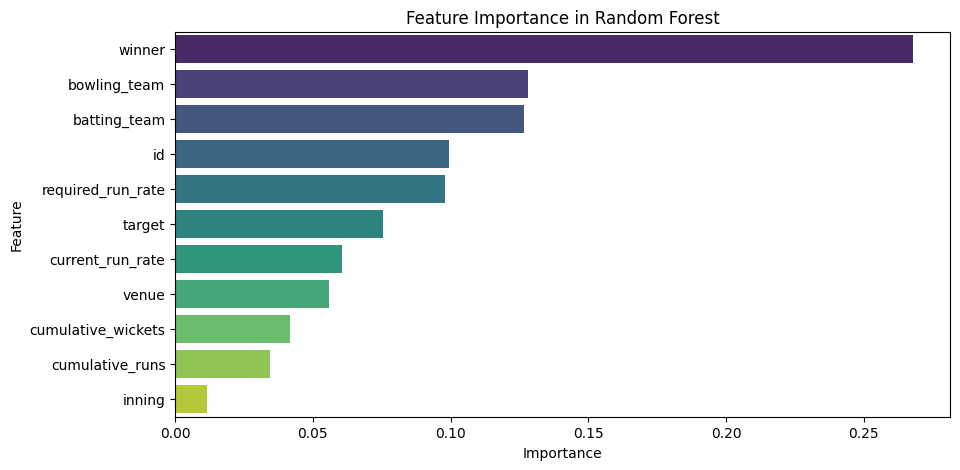

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/tuned_random_forest.pkl'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
file_path = "encoded_cricket_data.csv"
df = pd.read_csv(file_path)

# Define features and target
features = [col for col in df.columns if col not in ["win"]]  # Exclude target column
target = "win"

# Train-Test Split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.3, random_state=42)

# Standardizing numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define hyperparameter grid for tuning
param_grid = {
    "n_estimators": [100, 200, 300],  # Number of trees
    "max_depth": [10, 20, None],      # Depth of trees
    "min_samples_split": [2, 5, 10]   # Minimum samples required to split a node
}

# Perform Grid Search with 3-Fold Cross-Validation
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=2)
grid_search.fit(X_train_scaled, y_train)

# Get best parameters
best_params = grid_search.best_params_
print(f"\n✅ Best Hyperparameters for RFC: {best_params}")

# Train the best Random Forest model with optimized parameters
best_rf = RandomForestClassifier(**best_params, random_state=42)
best_rf.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = best_rf.predict(X_train_scaled)
y_test_pred = best_rf.predict(X_test_scaled)

# Evaluation
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n✅ Tuned RFC Accuracy - Train: {train_accuracy:.4f}, Test: {test_accuracy:.4f}")
print("\n📊 Classification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

print("\n🔍 Confusion Matrix (Test Data):")
print(confusion_matrix(y_test, y_test_pred))

# Feature Importance Analysis
feature_importances = best_rf.feature_importances_
importance_df = pd.DataFrame({"Feature": features, "Importance": feature_importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
plt.title("Feature Importance in Random Forest")
plt.show()

# Save the trained model
model_path = "/mnt/data/tuned_random_forest.pkl"
joblib.dump(best_rf, model_path)
print(f"\n✅ Model saved successfully at: {model_path}")

In [5]:
import joblib
import os

# Define a valid local path
model_dir = "models"  # You can change this to any existing directory
os.makedirs(model_dir, exist_ok=True)  # Ensure the directory exists

model_path = os.path.join(model_dir, "tuned_random_forest.pkl")

# Save the trained model
joblib.dump(best_rf, model_path)
print(f"\n✅ Model saved successfully at: {model_path}")



✅ Model saved successfully at: models/tuned_random_forest.pkl


In [7]:
import joblib
import numpy as np

# Load the trained model
model_path = "models/tuned_random_forest.pkl"  # Adjust the path if necessary
loaded_model = joblib.load(model_path)

# Select a sample row from the dataset (excluding the target column 'win')
sample_data = df.drop(columns=["win"]).iloc[0]  # Take the first row as an example

# Convert to a NumPy array and reshape for prediction
sample_data_array = np.array(sample_data).reshape(1, -1)

# Make a prediction
prediction = loaded_model.predict(sample_data_array)

# Display the result
print(f"Predicted Match Outcome: {'Win' if prediction[0] == 1 else 'Loss'}")


Predicted Match Outcome: Win
